In [2]:
# Importar las librerías que usaremos al inicio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ¡Veamos qué cargamos!
print(df.head())
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

Limpieza de TotalCharges

In [3]:
# Vamos a investigar qué filas no son numéricas
# pd.to_numeric convierte a número. Con 'errors='coerce'', los valores que fallan (como ' ') se vuelven NaN (Nulos).
# Luego .isnull() nos dice cuáles son esos.
problematic_rows = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]

print(f"Se encontraron {len(problematic_rows)} filas con problemas en TotalCharges.")
print("Veamos esas filas:")

# Mostramos solo las columnas clave para entender el problema
# Deberías notar que 'tenure' (antigüedad) es 0 en todas ellas.
print(problematic_rows[['tenure', 'MonthlyCharges', 'TotalCharges']])

Se encontraron 11 filas con problemas en TotalCharges.
Veamos esas filas:
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             


Arreglar la Columna

In [4]:
# 1. Convertimos la columna. Los ' ' se volverán NaN (un valor nulo de Pandas)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Rellenamos esos NaN con 0.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# --- Verificación ---
# Ahora comprobemos que todo esté en orden.
print("--- Verificación Post-Limpieza ---")

# 1. ¿Quedaron nulos? (Debería decir 0)
print(f"Valores nulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")

# 2. ¿Cómo se ve el df.info() ahora?
# (Busca TotalCharges, debería ser float64)
print("\nNuevo df.info():")
df.info()

--- Verificación Post-Limpieza ---
Valores nulos en TotalCharges: 0

Nuevo df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Con

Análisis de la Variable Objetivo (Churn)

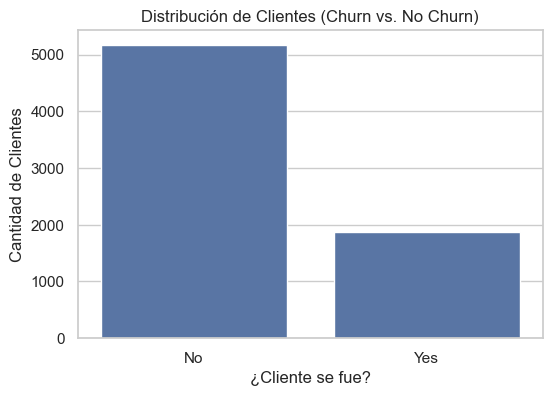

Porcentaje de Churn:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [5]:
# Configurar el estilo de los gráficos
sns.set(style="whitegrid")

# 1. Gráfico de la variable objetivo (Churn)
plt.figure(figsize=(6, 4)) # Definimos el tamaño del gráfico
sns.countplot(data=df, x='Churn')
plt.title('Distribución de Clientes (Churn vs. No Churn)')
plt.xlabel('¿Cliente se fue?')
plt.ylabel('Cantidad de Clientes')
plt.show()

# 2. Mostrar los porcentajes
churn_percentage = (df['Churn'].value_counts(normalize=True) * 100).round(2)
print("Porcentaje de Churn:")
print(churn_percentage)

## Paso 7: Análisis de Churn por Servicios y Tipo de Contrato

Ahora que sabemos la tasa general de fuga (26.6%), necesitamos profundizar para entender *quiénes* se van.

En este paso, cruzaremos la variable `Churn` con las características categóricas más importantes (`Contract`, `InternetService`, `TechSupport` y `PaymentMethod`) para encontrar los perfiles de clientes con mayor riesgo.

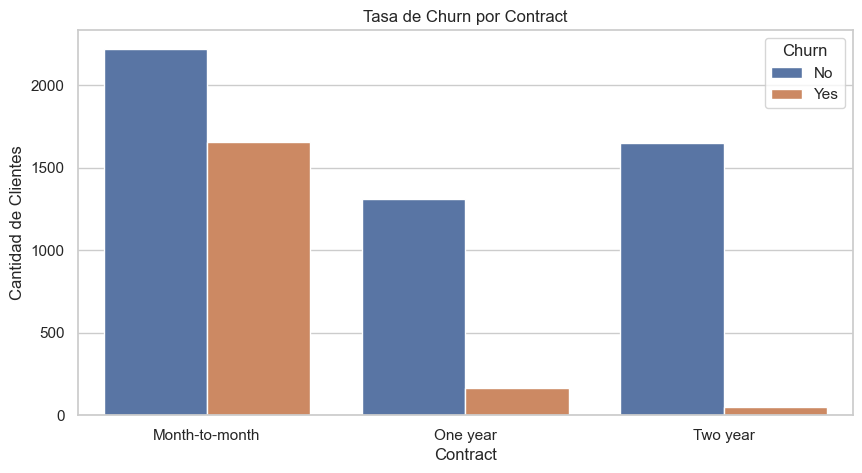

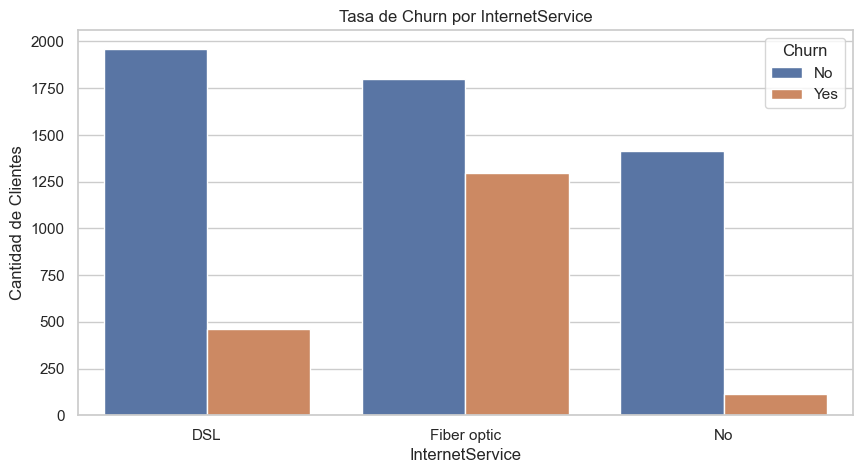

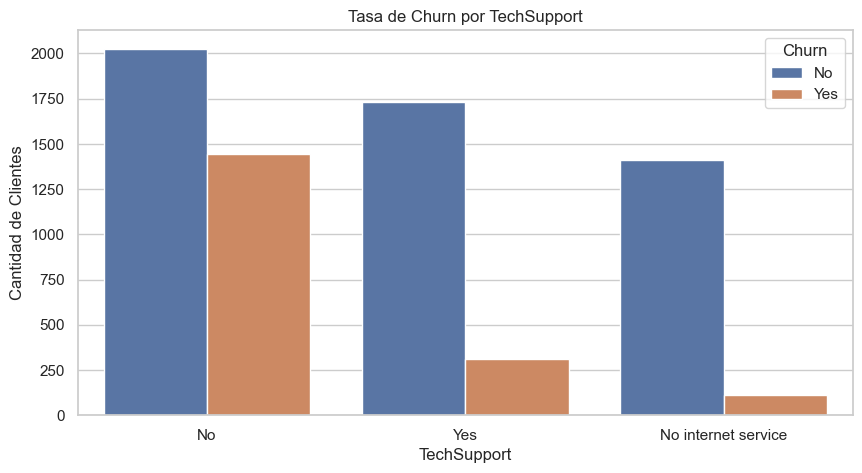

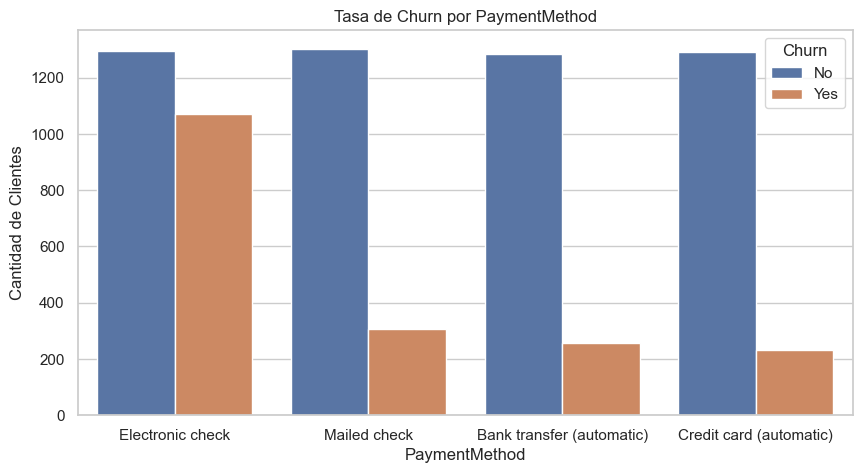

In [6]:
# Lista de columnas categóricas que queremos analizar
categorical_features = ['Contract', 'InternetService', 'TechSupport', 'PaymentMethod']

# Creamos un gráfico para cada una
for feature in categorical_features:
    plt.figure(figsize=(10, 5)) # Definimos el tamaño
    # Creamos un countplot que separa por 'Churn' usando el parámetro 'hue'
    sns.countplot(data=df, x=feature, hue='Churn')
    plt.title(f'Tasa de Churn por {feature}')
    plt.xlabel(feature)
    plt.ylabel('Cantidad de Clientes')
    plt.legend(title='Churn')
    plt.show()

---
### 💡 Hallazgos (Insights) del Paso 7

Los gráficos de arriba son muy reveladores:

1.  **Contrato (Contract):** Este es el factor más claro. Los clientes con contrato **`Month-to-month`** (mes a mes) tienen una tasa de fuga *dramáticamente* superior a los clientes con contratos de 1 o 2 años.
2.  **Soporte Técnico (TechSupport):** Los clientes que **NO** tienen soporte técnico (`No`) se van mucho más. Esto sugiere que se frustran ante un problema y no tienen a quién recurrir.
3.  **Servicio de Internet:** Los clientes con **`Fiber optic`** (Fibra Óptica) se van más que los de `DSL`. Esto es contraintuitivo (la fibra suele ser mejor) y podría ser un buen punto para un análisis más profundo. Quizás es más cara o la instalación es problemática.

Relación del Churn con Variables Numéricas

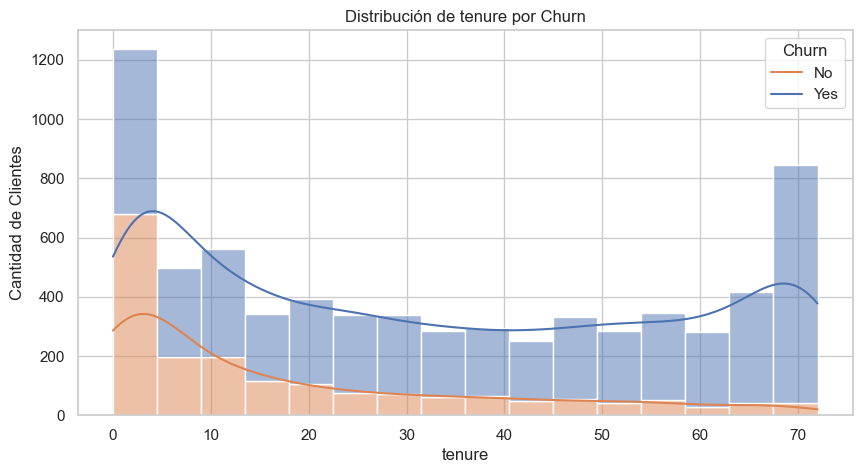

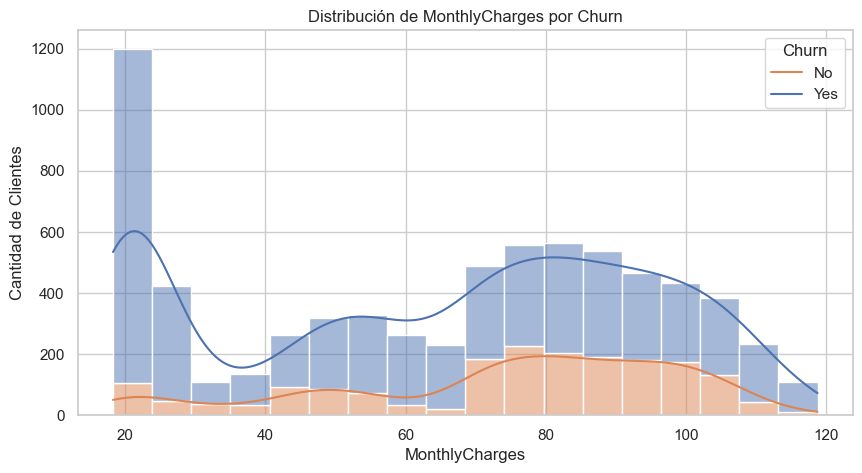

In [7]:
# Lista de columnas numéricas que queremos analizar
numerical_features = ['tenure', 'MonthlyCharges']

# Creamos un gráfico para cada una
for feature in numerical_features:
    plt.figure(figsize=(10, 5)) # Definimos el tamaño
    
    # Creamos un histograma, separando por 'Churn'
    # 'multiple="stack"' apila las barras de 'Yes' y 'No'
    sns.histplot(data=df, x=feature, hue='Churn', multiple="stack", kde=True) 
    
    plt.title(f'Distribución de {feature} por Churn')
    plt.xlabel(feature)
    plt.ylabel('Cantidad de Clientes')
    plt.legend(title='Churn', labels=['No', 'Yes'])
    plt.show()